# Pré-processamento — SOP (PCOS)

Limpeza, engenharia de atributos, split estratificado e pipeline sklearn.

- **Entrada:** `src/db/models/polycystic-ovary-syndrome-pcos/PCOS_infertility.csv`
- **Artefato:** `src/db/outputs/polycystic-ovary-syndrome-pcos/02-preprocessamento/artifacts/dados_preprocessados.joblib`
- **Próximo:** notebook `03_modelagem_treino.ipynb`


## 1 - Setup e carga


In [1]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def encontrar_raiz() -> Path:
    atual = Path.cwd().resolve()
    for candidato in [atual, *atual.parents]:
        if (candidato / "src" / "db").is_dir():
            return candidato
    raise FileNotFoundError("Raiz do repositório não encontrada.")

RAIZ = encontrar_raiz()
OUTPUT_BASE = RAIZ / "src/db/outputs/polycystic-ovary-syndrome-pcos"

CAMINHO_CSV = RAIZ / "src/db/models/polycystic-ovary-syndrome-pcos/PCOS_infertility.csv"
PASTA_BASE = OUTPUT_BASE / "02-preprocessamento"
PASTA_FIGURAS = PASTA_BASE / "figures"
PASTA_METRICAS = PASTA_BASE / "metrics"
PASTA_ARTEFATOS = PASTA_BASE / "artifacts"

for pasta in (PASTA_FIGURAS, PASTA_METRICAS, PASTA_ARTEFATOS):
    pasta.mkdir(parents=True, exist_ok=True)

LIMITE_DETECCAO = 1.99
COLUNA_ALVO = "pcos"
SEMENTE = 42


In [2]:
dados = pd.read_csv(CAMINHO_CSV)
dados.columns = dados.columns.str.strip()
dados = dados.rename(columns={
    "I   beta-HCG(mIU/mL)": "beta_hcg_i",
    "II    beta-HCG(mIU/mL)": "beta_hcg_ii",
    "AMH(ng/mL)": "amh",
    "PCOS (Y/N)": "pcos",
})

for col in ("beta_hcg_i", "beta_hcg_ii", "amh"):
    dados[col] = pd.to_numeric(dados[col], errors="coerce")

# Valores no limite de detecção viram ausentes
for col in ("beta_hcg_i", "beta_hcg_ii"):
    dados.loc[dados[col] == LIMITE_DETECCAO, col] = np.nan

# Engenharia de atributos
dados["beta_hcg_max"] = dados[["beta_hcg_i", "beta_hcg_ii"]].max(axis=1)
dados["beta_hcg_diff"] = (dados["beta_hcg_i"] - dados["beta_hcg_ii"]).abs()
dados["beta_hcg_ratio"] = dados["beta_hcg_i"] / dados["beta_hcg_ii"].replace(0, np.nan)
dados["amh_alto"] = (dados["amh"] >= 4.5).astype(int)
dados["beta_i_censurado"] = dados["beta_hcg_i"].isna().astype(int)
dados["beta_ii_censurado"] = dados["beta_hcg_ii"].isna().astype(int)

dados_modelagem = dados.drop(columns=["Sl. No", "Patient File No."], errors="ignore")
colunas_atributos = [c for c in dados_modelagem.columns if c != COLUNA_ALVO]
atributos = dados_modelagem[colunas_atributos]
rotulo = dados_modelagem[COLUNA_ALVO]

print("Atributos:", colunas_atributos)
print("Dimensão:", dados_modelagem.shape)
print("Ausentes por coluna:\n", atributos.isna().sum())


Atributos: ['beta_hcg_i', 'beta_hcg_ii', 'amh', 'beta_hcg_max', 'beta_hcg_diff', 'beta_hcg_ratio', 'amh_alto', 'beta_i_censurado', 'beta_ii_censurado']
Dimensão: (541, 10)
Ausentes por coluna:
 beta_hcg_i           191
beta_hcg_ii          307
amh                    1
beta_hcg_max         179
beta_hcg_diff        319
beta_hcg_ratio       319
amh_alto               0
beta_i_censurado       0
beta_ii_censurado      0
dtype: int64


## 2 - Correlação com o alvo


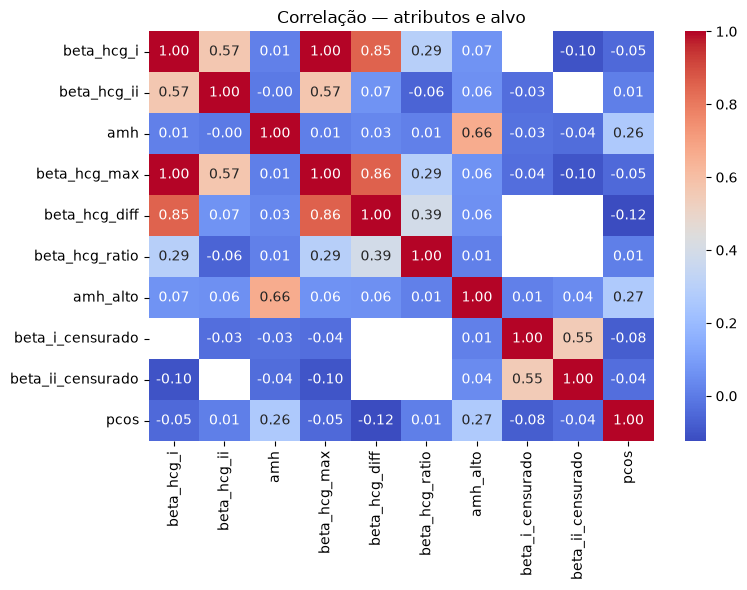

In [3]:
matriz = dados_modelagem[colunas_atributos + [COLUNA_ALVO]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlação — atributos e alvo")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "correlacao_preprocessamento.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)


## 3 - Split estratificado e preprocessador


In [4]:
atributos_treino, atributos_teste, rotulo_treino, rotulo_teste = train_test_split(
    atributos,
    rotulo,
    test_size=0.2,
    random_state=SEMENTE,
    stratify=rotulo,
)

preprocessador = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), colunas_atributos),
])

print("Treino:", atributos_treino.shape, "| Teste:", atributos_teste.shape)
print("Proporção PCOS=1 — treino:", round(rotulo_treino.mean(), 3))
print("Proporção PCOS=1 — teste:", round(rotulo_teste.mean(), 3))
print(preprocessador)


Treino: (432, 9) | Teste: (109, 9)
Proporção PCOS=1 — treino: 0.326
Proporção PCOS=1 — teste: 0.33
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['beta_hcg_i', 'beta_hcg_ii', 'amh',
                                  'beta_hcg_max', 'beta_hcg_diff',
                                  'beta_hcg_ratio', 'amh_alto',
                                  'beta_i_censurado', 'beta_ii_censurado'])])


## 4 - Salvar artefato


In [5]:
joblib.dump(
    {
        "atributos_treino": atributos_treino,
        "atributos_teste": atributos_teste,
        "rotulo_treino": rotulo_treino,
        "rotulo_teste": rotulo_teste,
        "colunas_atributos": colunas_atributos,
        "preprocessador": preprocessador,
        "semente": SEMENTE,
        "coluna_alvo": COLUNA_ALVO,
    },
    PASTA_ARTEFATOS / "dados_preprocessados.joblib",
)
print("Artefato salvo:", PASTA_ARTEFATOS / "dados_preprocessados.joblib")


Artefato salvo: E:\_git\fiap\fase1\tech-challenge-fase1\src\db\outputs\polycystic-ovary-syndrome-pcos\02-preprocessamento\artifacts\dados_preprocessados.joblib


In [6]:
pacote = joblib.load(PASTA_ARTEFATOS / "dados_preprocessados.joblib")
assert len(pacote["colunas_atributos"]) >= 3
assert len(pacote["atributos_treino"]) + len(pacote["atributos_teste"]) == len(atributos)
print("Validação OK")


Validação OK
